# Chapter 1 — The Mathematical Foundations

This chapter is a **pre-requisite mathematical foundation** for the generative modeling chapters that follow.

## Learning Objectives
By the end of this chapter, you should be able to:
1. Explain **random variables and expectations**
2. Understand **rules of expectations**
3. Know the difference between **conditional** and **marginal** distributions
4. Understand **Jensen’s inequality**
5. Manipulate the relationships between **joint**, **conditional** and **marginal** distributions
6. Understand **Law of Total Expectations** and **Law of Variance**
7. Understand the relationship between **Kullback–Leibler (KL) Divergence**, **Entropy**, and **Cross-Entropy** and **Mutual Information**
8. Know the concept of **Maximum Likelihood Estimations**
9. Know how **Monter Carlo Estimation** works

## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)

## 1. Random Variables and Expectation

Let $X$ be a random variable.

### Discrete
$
\mathbb{E}[X] = \sum_x x\,p(x)
$

### Continuous
$
\mathbb{E}[X] = \int x\,p(x)\,dx
$

More generally, for a function $f$:
$$
\mathbb{E}[f(X)] = \sum_x f(x)\,p(x) \quad\text{or}\quad \int f(x)\,p(x)\,dx
$$

**Interpretation:** expectation is a **weighted average** value of a function under the distribution.


In [ ]:
# Discrete example
x = np.array([0, 1, 2, 3], dtype=float)
p = np.array([0.1, 0.2, 0.4, 0.3], dtype=float)

# make sure it is a true probability distribution
p = p / p.sum()

E_X  = np.sum(x * p)
E_X2 = np.sum((x**2) * p)

# note that expected values is just a number

E_X, E_X2

(1.9, 4.5)

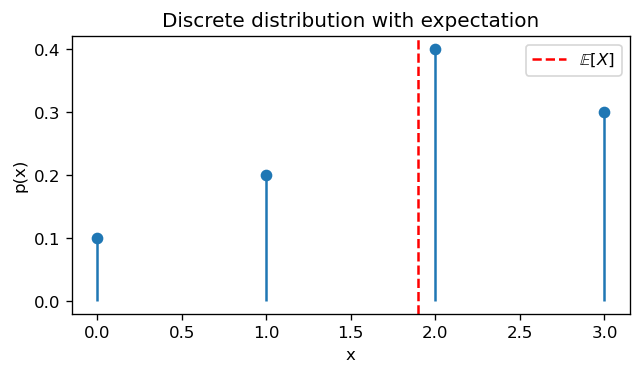

In [27]:
fig, ax = plt.subplots(figsize=(6,3))

ax.stem(x, p, basefmt=" ")
ax.axvline(E_X, color="red", linestyle="--", label=r"$\mathbb{E}[X]$")

ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("Discrete distribution with expectation")
ax.legend()

plt.show()


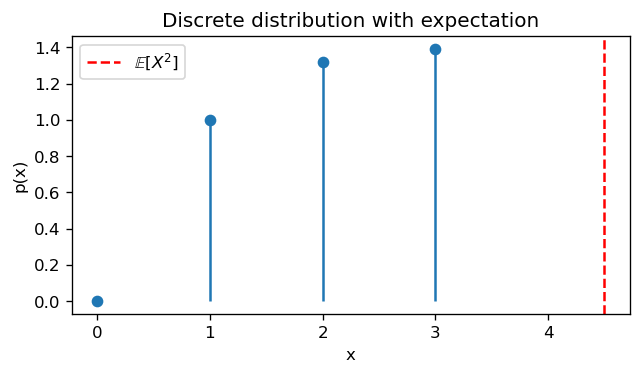

In [28]:
fig, ax = plt.subplots(figsize=(6,3))

ax.stem(x, x**p, basefmt=" ")
ax.axvline(E_X2, color="red", linestyle="--", label=r"$\mathbb{E}[X^2]$")

ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("Discrete distribution with expectation")
ax.legend()

plt.show()

In [29]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

x = np.array([-2, -1, 0, 1, 2], dtype=float)
fig, ax = plt.subplots(figsize=(6,3))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(0, 0.8)
ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("Expectation as balance point")

stem = ax.stem(x, np.zeros_like(x), basefmt=" ")
exp_line = ax.axvline(0, linestyle="--")
exp_text = ax.text(-2.4, 0.72, "")

def frame(t):
    w = (np.sin(2*np.pi*t/80) + 1)/2
    p = np.array([0.45*(1-w), 0.15*(1-w), 0.10, 0.15*w, 0.45*w], dtype=float)
    p = p/p.sum()
    E = np.sum(x*p)

    markerline, stemlines, baseline = stem
    markerline.set_ydata(p)
    stemlines.set_segments([[(xi, 0), (xi, pi)] for xi, pi in zip(x, p)])
    exp_line.set_xdata([E, E])
    exp_text.set_text(f"E[X] = {E:.3f}")
    return markerline, stemlines, exp_line, exp_text

anim = FuncAnimation(fig, frame, frames=80, interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## 2. Rules of Expectation (Linearity)

For constants $a,b,c$:
$$
\mathbb{E}[aX + bY + c] = a\,\mathbb{E}[X] + b\,\mathbb{E}[Y] + c
$$

Holds even if $X$ and $Y$ are dependent.

Other immediate consequences:
$$
\mathbb{E}\left[\sum_i X_i\right] = \sum_i \mathbb{E}[X_i]
$$
$$
\mathbb{E}[c] = c
$$


### Testing Empirically

We can use a monte carlo experiment to generate random numbers for X and Y and show that the equation above holds. 

In [ ]:
# Monte Carlo check of linearity (including dependence)
N = 200_000

# Create an X based on standard normal
X = np.random.normal(loc=0.0, scale=1.0, size=N)

# Create a Y that is correlated with X
Y = 0.7*X + np.random.normal(loc=1.0, scale=1.5, size=N)  # correlated with X

# mean representation of linearity of expectation
lhs = np.mean(2*X + 3*Y + 5)
rhs = 2*np.mean(X) + 3*np.mean(Y) + 5

# note that they are almost the same and the error is very small 
(lhs, rhs, abs(lhs-rhs))

(8.020601919467802, 8.020601919467804, 1.7763568394002505e-15)

## 3. Conditional Expectation

$$
\mathbb{E}[X \mid Y=y] = \sum_x x\,p(x\mid y)
$$

**Key point:** $$\mathbb{E}[X\mid Y]$$ is a random variable (a function of $Y$).



### Simple discrete visual example: 

Assume that $X$ takes discrete values $\{1,2,3,4\}$ and $Y$ is **binary**, with $Y\in\{0,1\}$. We also assume a joint distribution $p(x,y)$ given explicitly in a table.

The conditional expectation is computed as:
$$
\mathbb{E}[X\mid Y=y] = \sum_x x\,p(x\mid y)
$$

Visually:
- Fix a value of $Y$
- Look only at the column corresponding to that $Y$
- Take the **weighted average** of the $X$ values in that column

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Define discrete X and Y
X_vals = np.array([1, 2, 3, 4])
Y_vals = np.array([0, 1])

# Joint distribution p(x,y)
# rows: X = 1,2,3,4
# cols: Y = 0,1
p_xy = np.array([
    [0.20, 0.05],
    [0.25, 0.10],
    [0.10, 0.25],
    [0.05, 0.00]
])


# Sanity check probabilities should sum to 1
assert np.isclose(p_xy.sum(), 1.0)

# Marginals sum across columns for p(y|x)
p_y = p_xy.sum(axis=0)
print("p(y=0):", p_y[0])
print("p(y=1):", p_y[1])
p_x_given_y = p_xy / p_y
print("p(x|y=0):", p_x_given_y[:,0])
print("p(x|y=1):", p_x_given_y[:,1])

# Conditional expectations where @ is matrix multiplication
E_X_given_Y = X_vals @ p_x_given_y

p_y, E_X_given_Y
print("E_X_given_y0:", E_X_given_Y[0])
print("E_X_given_y1:", E_X_given_Y[1])


p(y=0): 0.6000000000000001
p(y=1): 0.4
p(x|y=0): [0.33333333 0.41666667 0.16666667 0.08333333]
p(x|y=1): [0.125 0.25  0.625 0.   ]
E_X_given_y0: 1.9999999999999998
E_X_given_y1: 2.5


### Table view of the joint distribution

Each column is a conditional distribution $p(x\mid Y=y)$ after normalization.


In [36]:
# Display joint and conditional distributions
print("Joint distribution p(x,y):")
print(p_xy)

print("\nMarginal p(y):")
print(p_y)

print("\nConditional distributions p(x|y):")
for j, y in enumerate(Y_vals):
    print(f"Y={y}: p(x|y) =", p_x_given_y[:,j])

Joint distribution p(x,y):
[[0.2  0.05]
 [0.25 0.1 ]
 [0.1  0.25]
 [0.05 0.  ]]

Marginal p(y):
[0.6 0.4]

Conditional distributions p(x|y):
Y=0: p(x|y) = [0.33333333 0.41666667 0.16666667 0.08333333]
Y=1: p(x|y) = [0.125 0.25  0.625 0.   ]


This means that p(y=0) = 0.6 across all values of x, and p(y=1)=0.4 across all values of x. Similarly, $p(x\mid y)$ is normalizing $p(x, y)$ by $p(y)$


### Visual: conditional expectation as a weighted average

For each value of $Y$:
- bars show $$p(x\mid Y=y)$$
- the dashed line marks $$\mathbb{E}[X\mid Y=y]$$

This is the **discrete analogue** of “averaging $X$ inside each $Y$ bin.”


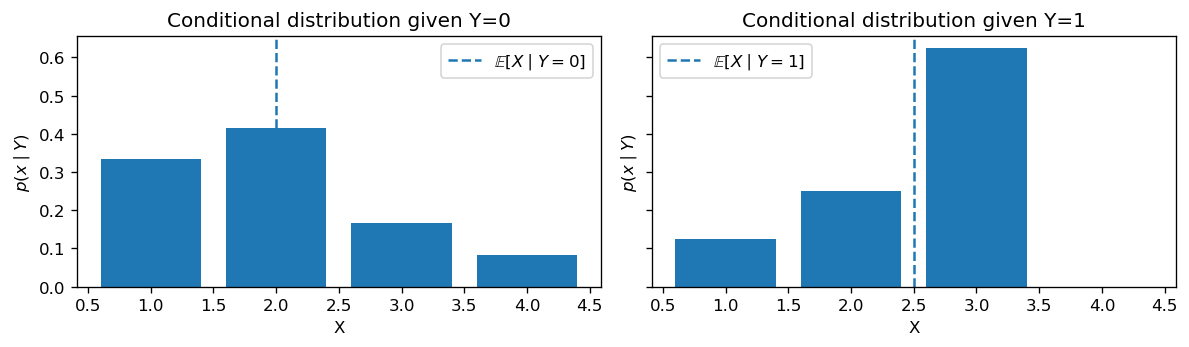

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

for j, y in enumerate(Y_vals):
    ax = axes[j]
    ax.bar(X_vals, p_x_given_y[:,j])
    ax.axvline(E_X_given_Y[j], linestyle="--", label=rf"$\mathbb{{E}}[X\mid Y={y}]$")
    ax.set_title(f"Conditional distribution given Y={y}")
    ax.set_xlabel("X")
    ax.set_ylabel(r"$p(x\mid Y)$")
    ax.legend()

plt.tight_layout()
plt.show()

### Summary

- $\mathbb{E}[X\mid Y]$ is **not a number** but it is a **function of $Y$**
- In this example:
  $
  \mathbb{E}[X\mid Y=0] \neq \mathbb{E}[X\mid Y=1]
  $
- For discrete variables:
  - **Fix $Y=y$**
  - Normalize the column $p(x,y)$ to get $p(x\mid y)$
  - Compute a **weighted average of $X$**

## 4. Marginal Expectation (Law of Total Expectation)

$$
\mathbb{E}[X] = \mathbb{E}_Y\left[\mathbb{E}[X\mid Y]\right]
$$


In [38]:
# Simple discrete total expectation example
P_Y = np.array([0.6, 0.4])           # P(Y=0), P(Y=1)
E_X_given_Y = np.array([1.0, 3.0])   # E[X|Y=0], E[X|Y=1]
E_X_total = np.sum(P_Y * E_X_given_Y)
E_X_total

1.8000000000000003

## 5. Marginal Distribution and Its Relationship to Expectations

A **marginal distribution** describes the probability behavior of a single random variable **by itself**, ignoring all other variables. It is obtained by “averaging out” (summing or integrating over) the other variables in a joint distribution.
### Definition

Suppose we have two random variables $X$ and $Y$ with joint distribution $p(x,y)$.

#### Discrete case
$$
p(x) = \sum_y p(x,y)
$$

#### Continuous case
$$
p(x) = \int p(x,y)\,dy
$$

The result $p(x)$ is the **marginal distribution of $X$**.

### Intuition

Think of a table or surface describing $p(x,y)$.

- The **joint distribution** tells you how $(X,Y)$ behave together.
- The **marginal distribution** of $X$ collapses this information down to **only $X$** by summing or integrating over all possible values of $Y$.

In words:

> A marginal distribution describes what $X$ looks like when you do not care about $Y$.

### Relationship to Expectations

An **expectation** is always computed with respect to a distribution. When we compute $\mathbb{E}[X]$, we use the **marginal distribution of $X$**, not the joint distribution.

#### Discrete case
$$
\mathbb{E}[X] = \sum_x x\,p(x)
$$

#### Continuous case
$$
\mathbb{E}[X] = \int x\,p(x)\,dx
$$

Even if $X$ is part of a larger joint system, its expectation depends **only** on its marginal.

## Expectation via the joint distribution

The same expectation can be written using the joint distribution:
$$
\mathbb{E}[X] = \sum_{x,y} x\,p(x,y)
$$

This works because summing over $y$ first produces the marginal:
$$
\sum_{x,y} x\,p(x,y)
=
\sum_x x\!\left(\sum_y p(x,y)\right)
=
\sum_x x\,p(x)
$$

Start with:
$$
\mathbb{E}[X] = \sum_{x,y} x\,p(x,y).
$$

Now rearrange the sum:
$$
\sum_{x,y} x\,p(x,y)
=
\sum_x \sum_y x\,p(x,y).
$$

Because $x$ does **not** depend on $y$, we can factor it out:
$$
=
\sum_x x \left(\sum_y p(x,y)\right).
$$

The inner sum:
$$
\sum_y p(x,y)
$$
is **exactly the marginal distribution of $X$**, denoted $p(x)$.

So we obtain:
$$
\sum_x x\,p(x) = \mathbb{E}[X].
$$

This shows that:

> **Marginalization is the step that makes expectations well-defined for individual variables.**

### Summary

- A **marginal distribution** isolates one variable from a joint system.
- **Expectations of a variable are always taken with respect to its marginal distribution.**
- Joint distributions contain more information, but expectations reduce that information via marginalization.

### Marginal Distributions from a 2D Joint Distribution

Let us look at a **simple 2D discrete example** of a joint distribution $p(x,y)$ and shows how to compute and visualize:

- the **marginal distribution** $p(x) = \sum_y p(x,y)$  
- the **marginal distribution** $p(y) = \sum_x p(x,y)$

We use a small grid so the summations can be seen clearly.

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

#### Define a small joint distribution $p(x,y)$

We choose discrete supports:
- $X \in \{1,2,3,4\}$
- $Y \in \{0,1,2\}$

and define a valid joint distribution $p(x,y)$ whose entries sum to 1.


In [40]:
X_vals = np.array([1, 2, 3, 4])
Y_vals = np.array([0, 1, 2])

# rows = X, cols = Y
p_xy = np.array([
    [0.05, 0.10, 0.05],
    [0.10, 0.20, 0.05],
    [0.05, 0.20, 0.10],
    [0.05, 0.03, 0.02]
], dtype=float)

print("Sum of all probabilities:", p_xy.sum())

Sum of all probabilities: 1.0


#### Visualize the joint distribution $p(x,y)$ as a colorful heatmap

Each colored cell is a probability mass $p(x,y)$.

- Brighter color = higher probability mass  
- Rows correspond to $X$ values  
- Columns correspond to $Y$ values


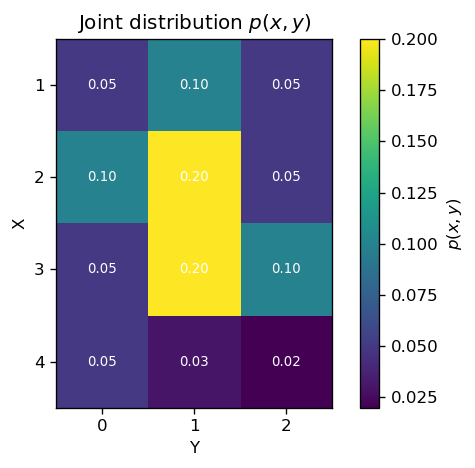

In [41]:
fig, ax = plt.subplots(figsize=(5.2, 4.0))

im = ax.imshow(p_xy, cmap="viridis")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$p(x,y)$")

ax.set_xticks(range(len(Y_vals)))
ax.set_xticklabels(Y_vals)
ax.set_yticks(range(len(X_vals)))
ax.set_yticklabels(X_vals)

ax.set_xlabel("Y")
ax.set_ylabel("X")
ax.set_title("Joint distribution $p(x,y)$")

# Annotate cells with probabilities
for i in range(len(X_vals)):
    for j in range(len(Y_vals)):
        ax.text(j, i, f"{p_xy[i,j]:.2f}", ha="center", va="center", color="white", fontsize=8)

plt.tight_layout()
plt.show()

#### Compute marginals $p(x)$ and $p(y)$

Marginal of \(X\) (sum over \(Y\)):
$$
p(x) = \sum_y p(x,y)
$$

Marginal of \(Y\) (sum over \(X\)):
$$
p(y) = \sum_x p(x,y)
$$


In [42]:
p_x = p_xy.sum(axis=1)  # sum across columns (over Y)
p_y = p_xy.sum(axis=0)  # sum across rows (over X)

print("p(x) =", p_x, " sum =", p_x.sum())
print("p(y) =", p_y, " sum =", p_y.sum())

p(x) = [0.2  0.35 0.35 0.1 ]  sum = 1.0
p(y) = [0.25 0.53 0.22]  sum = 1.0


#### Show the marginal calculations explicitly (row sums and column sums)

- **Row sums** correspond to $p(x)$
- **Column sums** correspond to $p(y)$

This is exactly what marginalization does: it **collapses** a 2D distribution into 1D.


In [43]:
# Display row and column sums alongside the table in text form
print("Row sums (p(x)):")
for i, xv in enumerate(X_vals):
    print(f"  X={xv}: sum_y p({xv},y) = {p_x[i]:.2f}")

print("\nColumn sums (p(y)):")
for j, yv in enumerate(Y_vals):
    print(f"  Y={yv}: sum_x p(x,{yv}) = {p_y[j]:.2f}")

Row sums (p(x)):
  X=1: sum_y p(1,y) = 0.20
  X=2: sum_y p(2,y) = 0.35
  X=3: sum_y p(3,y) = 0.35
  X=4: sum_y p(4,y) = 0.10

Column sums (p(y)):
  Y=0: sum_x p(x,0) = 0.25
  Y=1: sum_x p(x,1) = 0.53
  Y=2: sum_x p(x,2) = 0.22


#### Side-by-side visualization: joint + marginals

- Left: joint heatmap $p(x,y)$
- Middle: marginal bar chart $p(x)$
- Right: marginal bar chart $p(y)$

This is the cleanest visual interpretation of marginalization:
- sum rows $\rightarrow p(x)$
- sum columns $\rightarrow p(y)$


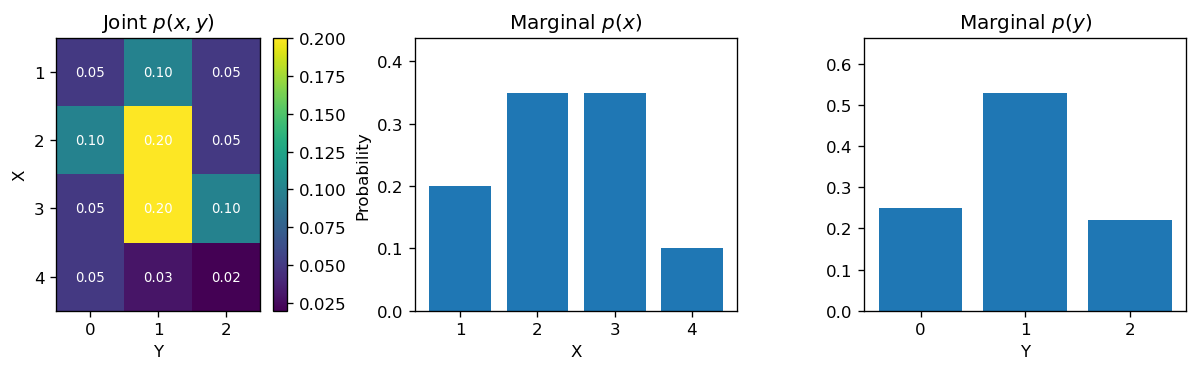

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))

# Joint heatmap
ax = axes[0]
im = ax.imshow(p_xy, cmap="viridis")
ax.set_title("Joint $p(x,y)$")
ax.set_xlabel("Y")
ax.set_ylabel("X")
ax.set_xticks(range(len(Y_vals)))
ax.set_xticklabels(Y_vals)
ax.set_yticks(range(len(X_vals)))
ax.set_yticklabels(X_vals)

for i in range(len(X_vals)):
    for j in range(len(Y_vals)):
        ax.text(j, i, f"{p_xy[i,j]:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Marginal p(x)
ax = axes[1]
ax.bar(X_vals, p_x)
ax.set_title("Marginal $p(x)$")
ax.set_xlabel("X")
ax.set_ylabel("Probability")
ax.set_ylim(0, max(p_x)*1.25)

# Marginal p(y)
ax = axes[2]
ax.bar(Y_vals, p_y)
ax.set_title("Marginal $p(y)$")
ax.set_xlabel("Y")
ax.set_ylim(0, max(p_y)*1.25)

plt.tight_layout()
plt.show()

#### Connect marginals to expectations

Once we have the marginal distributions, expectations follow immediately.

For example:
$$
\mathbb{E}[X] = \sum_x x\,p(x),
\quad
\mathbb{E}[Y] = \sum_y y\,p(y).
$$


In [45]:
E_X = np.sum(X_vals * p_x)
E_Y = np.sum(Y_vals * p_y)

print("E[X] =", E_X)
print("E[Y] =", E_Y)

E[X] = 2.35
E[Y] = 0.97


## Summary

- A **joint** distribution $p(x,y)$ describes how $(X,Y)$ behave together.
- The **marginal** distributions $p(x)$ and $p(y)$ describe each variable alone.
- Marginals are computed by **summing out** the other variable.



## 6 Conditionals and Bayes' rule

From the joint distribution:
$$
p(x,y) = p(x\mid y)p(y) = p(y\mid x)p(x)
$$

Rearranging gives **Bayes' rule**:
$$
p(y\mid x) = \frac{p(x\mid y)p(y)}{p(x)}
$$

Bayes' rule simply expresses **two ways of slicing the same joint distribution**.


In [46]:

# Conditional distributions
p_x_given_y = p_xy / p_y          # p(x|y)
p_y_given_x = (p_xy.T / p_x).T    # p(y|x)

print("p(x|y=0):", p_x_given_y[:,0])
print("p(x|y=1):", p_x_given_y[:,1])
print("p(y|x=0):", p_y_given_x[0])
print("p(y|x=1):", p_y_given_x[1])


p(x|y=0): [0.2 0.4 0.2 0.2]
p(x|y=1): [0.18867925 0.37735849 0.37735849 0.05660377]
p(y|x=0): [0.25 0.5  0.25]
p(y|x=1): [0.28571429 0.57142857 0.14285714]



### Expectations use marginal distributions

The expectation of a random variable depends **only on its marginal distribution**.

$$
\mathbb{E}[X] = \sum_x x\,p(x)
$$


In [51]:

E_X = np.sum(X_vals * p_x)
E_Y = np.sum(Y_vals * p_y)

print("E[X] =", E_X)
print("E[Y] =", E_Y)


E[X] = 2.35
E[Y] = 0.97



### Conditional expectations

The conditional expectation of $X$ given $Y=y$ is:
$$
\mathbb{E}[X\mid Y=y] = \sum_x x\,p(x\mid y)
$$

This is a **different number for each value of \(Y\)**.


In [49]:

E_X_given_y0 = np.sum(X_vals * p_x_given_y[:,0])
E_X_given_y1 = np.sum(X_vals * p_x_given_y[:,1])

print("E[X | Y=0] =", E_X_given_y0)
print("E[X | Y=1] =", E_X_given_y1)


E[X | Y=0] = 2.4000000000000004
E[X | Y=1] = 2.30188679245283



### Law of Total Expectation

The **law of total expectation** connects everything:

$$
\mathbb{E}[X] = \sum_y \mathbb{E}[X\mid Y=y]\,p(y)
$$

This says:
> The overall average of \(X\) is a **weighted average of its conditional averages**.


In [52]:

E_X_total = E_X_given_y0 * p_y[0] + E_X_given_y1 * p_y[1]

print("E[X] from total expectation =", E_X_total)


E[X] from total expectation = 1.82



## Summary

- **Joint distribution**: complete description of $(X,Y)$
- **Marginals**: collapse the joint by summing
- **Conditionals**: slice and renormalize the joint
- **Bayes' rule**: relates conditionals via marginals
- **Law of total expectation**: averages conditional expectations

All of these are different views of the **same probability object**.



#### Law of Total Expectation Example - Exam Scores by Section

Assume:

- $Y$ = section (Morning vs Evening)
- $X$ = exam score

The law states:
$$
\mathbb{E}[X] = \sum_y \mathbb{E}[X \mid Y=y]\,p(y).
$$

In words:

> The overall average score equals the weighted average of the section averages.

We visualize:
1. Section sizes $p(Y)$  
2. Section averages $\mathbb{E}[X\mid Y]$  
3. The weighted contributions $p(Y)\,\mathbb{E}[X\mid Y]$  
4. The overall mean $\mathbb{E}[X]$  
5. A small synthetic dataset to verify the same idea by direct averaging

In [53]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


#### Setup: Section proportions and section average scores

We assume:

- $p(Y=\mathrm{Morning}) = 0.6$
- $p(Y=\mathrm{Evening}) = 0.4$

And conditional (within-section) average scores:

- $\mathbb{E}[X\mid Y=\mathrm{Morning}] = 80$
- $\mathbb{E}[X\mid Y=\mathrm{Evening}] = 70$


In [54]:
sections = ["Morning", "Evening"]
pY = np.array([0.6, 0.4])          # p(Y)
EX_given_Y = np.array([80, 70])    # E[X | Y]

EX_total = np.sum(pY * EX_given_Y)

print("E[X] by total expectation =", EX_total)

E[X] by total expectation = 76.0



#### Visual 1: Section proportions $p(Y)$

This plot shows how the population is split between sections.

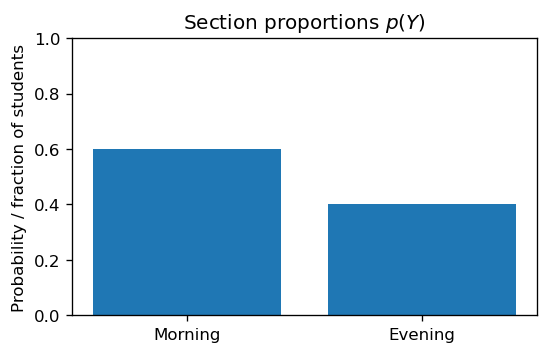

In [55]:
plt.figure(figsize=(5,3))
plt.bar(sections, pY)
plt.ylim(0, 1)
plt.ylabel("Probability / fraction of students")
plt.title("Section proportions $p(Y)$")
plt.show()


#### Visual 2: Section averages $\mathbb{E}[X\mid Y]$

This plot shows the average score **within each section**.


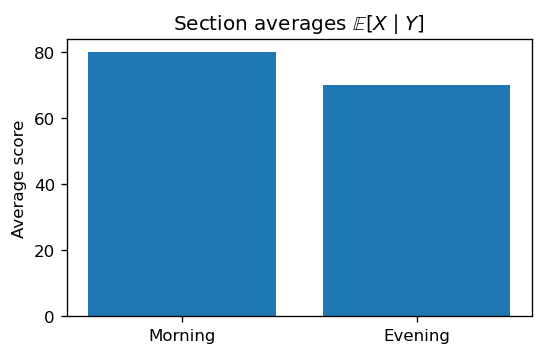

In [56]:
plt.figure(figsize=(5,3))
plt.bar(sections, EX_given_Y)
plt.ylabel("Average score")
plt.title("Section averages $\mathbb{E}[X\mid Y]$")
plt.show()


#### Visual 3: Weighted-average picture (the law of total expectation)

We compute:
$$
\mathbb{E}[X] = 0.6\cdot 80 + 0.4\cdot 70 = 76.
$$

Each section contributes:

- Morning contributes $0.6\times 80 = 48$
- Evening contributes $0.4\times 70 = 28$


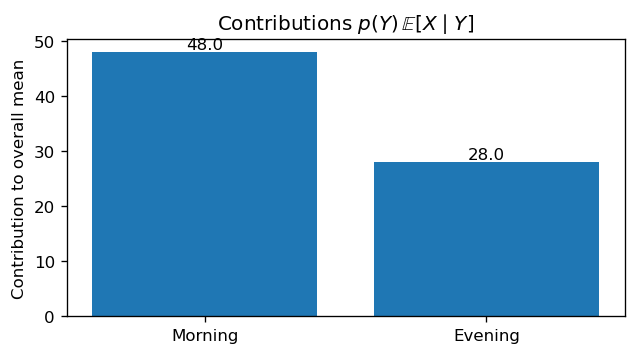

Contributions: [48. 28.] sum = 76.0


In [57]:
contrib = pY * EX_given_Y

plt.figure(figsize=(6,3))
plt.bar(sections, contrib)
plt.ylabel("Contribution to overall mean")
plt.title("Contributions $p(Y)\,\mathbb{E}[X\mid Y]$")

for i, v in enumerate(contrib):
    plt.text(i, v + 0.6, f"{v:.1f}", ha="center")

plt.show()

print("Contributions:", contrib, "sum =", contrib.sum())


## Visual 4: Put it all together

Side-by-side:
- $p(Y)$
- $\mathbb{E}[X\mid Y]$
- $p(Y)\,\mathbb{E}[X\mid Y]$
- $\mathbb{E}[X]$


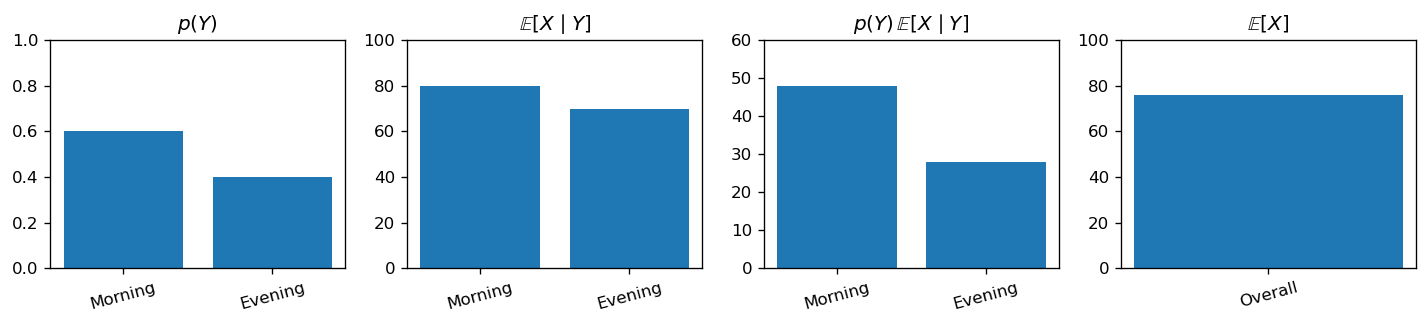

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))

axes[0].bar(sections, pY)
axes[0].set_ylim(0, 1)
axes[0].set_title("$p(Y)$")

axes[1].bar(sections, EX_given_Y)
axes[1].set_title("$\mathbb{E}[X\mid Y]$")
axes[1].set_ylim(0, 100)

axes[2].bar(sections, contrib)
axes[2].set_title("$p(Y)\,\mathbb{E}[X\mid Y]$")
axes[2].set_ylim(0, 60)

axes[3].bar(["Overall"], [EX_total])
axes[3].set_title("$\mathbb{E}[X]$")
axes[3].set_ylim(0, 100)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


#### Verify with a synthetic dataset

To make the law feel concrete, we can simulate students:

- 60% are assigned to Morning, scores centered near 80  
- 40% are assigned to Evening, scores centered near 70  

Then we compare:
- the **direct average** of all scores
- the **weighted average** of section means

These match closely (up to sampling noise).


In [59]:
N = 400
Y = np.random.choice([0, 1], size=N, p=pY)  # 0=Morning, 1=Evening

# Generate scores with some spread
scores = np.where(Y==0,
                  np.random.normal(loc=80, scale=8, size=N),
                  np.random.normal(loc=70, scale=8, size=N))

# Direct overall average
EX_direct = scores.mean()

# Conditional means from the simulated data
EX_morning = scores[Y==0].mean()
EX_evening = scores[Y==1].mean()

# Weighted average using empirical p(Y)
pY_emp = np.array([(Y==0).mean(), (Y==1).mean()])
EX_total_emp = pY_emp[0]*EX_morning + pY_emp[1]*EX_evening

print("Direct average of all scores:", EX_direct)
print("Empirical E[X|Morning], E[X|Evening]:", EX_morning, EX_evening)
print("Empirical p(Y):", pY_emp)
print("Weighted average (total expectation):", EX_total_emp)

Direct average of all scores: 75.20547083584216
Empirical E[X|Morning], E[X|Evening]: 78.80764626289046 69.68821480200876
Empirical p(Y): [0.605 0.395]
Weighted average (total expectation): 75.20547083584219



#### Visual 5: Synthetic score distributions by section

We plot histograms of scores for each section and mark the overall mean.

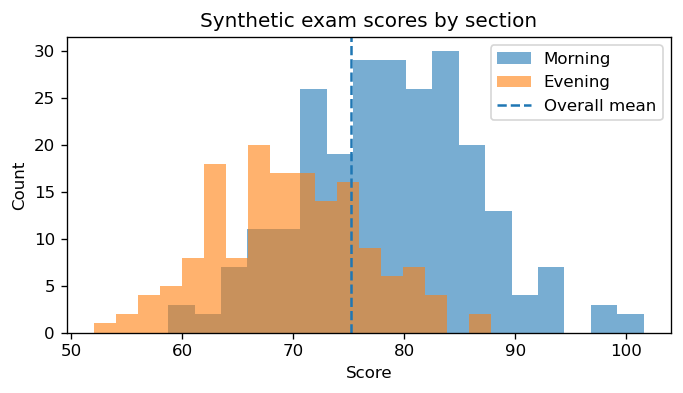

In [24]:
plt.figure(figsize=(6.5,3.2))
plt.hist(scores[Y==0], bins=18, alpha=0.6, label="Morning")
plt.hist(scores[Y==1], bins=18, alpha=0.6, label="Evening")
plt.axvline(scores.mean(), linestyle="--", label="Overall mean")

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Synthetic exam scores by section")
plt.legend()
plt.show()


## Summary
The law of total expectation says:
$$
\mathbb{E}[X] = \sum_y \mathbb{E}[X \mid Y=y]\,p(y).
$$

Visually:
- the **section proportions** provide the weights $p(y)$
- the **section averages** provide the conditional means $\mathbb{E}[X\mid Y=y]$
- the overall mean is a **weighted average of group means**


## 5. Variance, Covariance, Correlation

**Variance**

$$
\mathrm{Var}(X)
=
\mathbb{E}\!\left[(X-\mathbb{E}[X])^2\right]
=
\mathbb{E}[X^2] - (\mathbb{E}[X])^2
$$

**Covariance**

$$
\mathrm{Cov}(X,Y)
=
\mathbb{E}\!\left[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])\right]
$$

**Correlation**

$$
\rho_{XY}
=
\frac{\mathrm{Cov}(X,Y)}
{\sqrt{\mathrm{Var}(X)\,\mathrm{Var}(Y)}}
$$


In [ ]:
# E[X^2] vs (E[X])^2
Z = np.random.normal(size=200_000)
EX2 = np.mean(Z**2)
EX  = np.mean(Z)
(EX2, EX**2, EX2-EX**2)

(0.9962321669692806, 1.1695788970707868e-05, 0.9962204711803099)

In [ ]:
# Covariance/correlation example
X = np.random.normal(size=200_000)
Y = 2*X + np.random.normal(scale=0.5, size=200_000)

cov = np.mean((X-np.mean(X))*(Y-np.mean(Y)))
corr = cov / (np.std(X)*np.std(Y))
cov, corr

(1.9974464048528084, 0.9700904439349247)

## 6. Law of Total Variance

$$
\mathrm{Var}(X)
=
\mathbb{E}\!\left[\mathrm{Var}(X \mid Y)\right]
+
\mathrm{Var}\!\left(\mathbb{E}[X \mid Y]\right)
$$


### What the next Monte Carlo example illustrates

This simulation provides a **numerical verification** of the **Law of Total Variance**:

### How the example is constructed

- A binary variable $Y \in \{0,1\}$ is sampled with:
  $$
  P(Y=1)=0.4,\quad P(Y=0)=0.6
  $$

- The variable $X$ is generated **conditionally on $Y$**:
  - If $Y=0$, then $X \sim \mathcal{N}(0,1)$  
  - If $Y=1$, then $X \sim \mathcal{N}(3,2^2)$  

This creates two groups with **different means and different variances**.

### What each computed quantity represents

- `var_total`  
  The empirical variance of **all samples of $X$**, ignoring $Y$.

- `var_within`  
  The **average of the conditional variances**:
  $
  \mathbb{E}[\mathrm{Var}(X \mid Y)]
  $
  This captures the variability **within each group** where $Y$ defines the group. In other words, what is the average variability across groups defined by $Y$.

- `var_between`  
  The variance of the conditional means:
  $
  \mathrm{Var}(\mathbb{E}[X \mid Y])
  $
  This captures the variability **between groups** caused by different group means. In other words, what is the average variability across the means of each group. 

### Summary

The output shows that:
$
\texttt{var\_total}
\;\approx\;
\texttt{var\_within} + \texttt{var\_between}
$

This confirms that the total variability in $X$ can be decomposed into:
- **within-group randomness**, and
- **between-group differences in the conditional mean**.

In [62]:
# Monte Carlo illustration of total variance
N = 300_000
Y = np.random.binomial(1, 0.4, size=N)  # group indicator

# X|Y=0 ~ N(0,1), X|Y=1 ~ N(3,2)
X = np.where(Y==0, np.random.normal(0,1,size=N), np.random.normal(3,2,size=N))

var_total = np.var(X)
var_within = 0.5*(np.var(X[Y==0]) + np.var(X[Y==1]))
mean0, mean1 = np.mean(X[Y==0]), np.mean(X[Y==1])
var_between = np.var(np.where(Y==0, mean0, mean1))

var_total, var_within + var_between

(4.355836629866026, 4.650022890963639)

### Convex and Concave Functions (Geometric Intuition)

A function’s convexity or concavity describes **how it bends**.

### Convex function

A function $\phi(x)$ is **convex** if the line segment between any two points on the graph lies **above** the function.

Formally, for all $x_1, x_2$ and $\lambda \in [0,1]$:
$$
\phi(\lambda x_1 + (1-\lambda)x_2)
\;\le\;
\lambda \phi(x_1) + (1-\lambda)\phi(x_2)
$$

**Visual intuition**
- Draw two points on the curve
- Draw the straight line (chord) between them
- The curve stays **below** the line

**Common convex examples**
- $\phi(x)=x^2$
- $\phi(x)=|x|$
- $\phi(x)=e^x$

### Concave function

A function $\phi(x)$ is **concave** if the line segment between any two points on the graph lies **below** the function.

Formally:
$$
\phi(\lambda x_1 + (1-\lambda)x_2)
\;\ge\;
\lambda \phi(x_1) + (1-\lambda)\phi(x_2)
$$

**Visual intuition**
- Draw two points on the curve
- Draw the straight line between them
- The curve stays **above** the line

**Common concave examples**
- $\phi(x)=\log x$ (for $x>0$)
- $\phi(x)=\sqrt{x}$
- $\phi(x)=-x^2$


## 7. Jensen’s Inequality

If $\phi$ is **convex**:
$$
\phi(\mathbb{E}[X]) \le \mathbb{E}[\phi(X)]
$$

If $\phi$ is **concave** (e.g., $\log$), the inequality flips:
$$
\mathbb{E}[\log X] \le \log \mathbb{E}[X]
$$



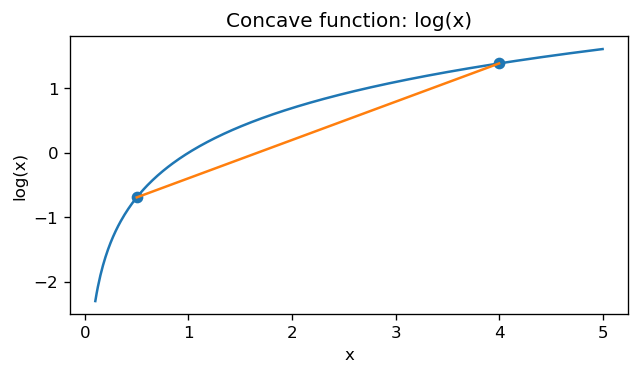

In [63]:
# Visual Jensen for log
xs = np.linspace(0.1, 5, 400)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(xs, np.log(xs))
ax.set_title("Concave function: log(x)")
ax.set_xlabel("x")
ax.set_ylabel("log(x)")

a, b = 0.5, 4.0
ax.plot([a,b], [np.log(a), np.log(b)])  # chord
ax.scatter([a,b], [np.log(a), np.log(b)])
plt.show()

In [64]:
# Jensen demo with log (concave)
X = np.random.lognormal(mean=0.0, sigma=1.0, size=200_000)  # positive
lhs = np.mean(np.log(X))
rhs = np.log(np.mean(X))
lhs, rhs, lhs <= rhs

(0.000632538165453497, 0.49687765422158064, True)

## 8. Entropy and Cross-Entropy

**Entropy**

$$
H(P) = -\sum_x p(x)\log p(x)
$$

**Cross-entropy**

$$
H(P,Q) = -\sum_x p(x)\log q(x)
$$



In [65]:
p = np.array([0.1, 0.9])
q = np.array([0.5, 0.5])

H_p = -np.sum(p*np.log(p))
H_pq = -np.sum(p*np.log(q))
H_p, H_pq

(0.3250829733914482, 0.6931471805599453)

#### Why entropy has the form $-\sum_x p(x)\log p(x)$

Entropy measures **uncertainty** or **surprise** in a probability distribution.

##### Step 1 — Why use $\log$?

We want a measure of surprise for a single outcome $x$ that:
- is **small** when $p(x)$ is large (likely outcomes are not surprising),
- is **large** when $p(x)$ is small (rare outcomes are surprising),
- adds nicely across independent events.

The function
$
-\log p(x)
$
satisfies all three:
- $p(x)\approx 1 \Rightarrow -\log p(x)\approx 0$
- $p(x)\ll 1 \Rightarrow -\log p(x)\gg 0$

This quantity is called the **information content** (or surprise) of outcome $x$.

##### Step 2 — Why multiply by $p(x)$?

Entropy is the **average surprise**:
$
H(P) = \mathbb{E}[-\log p(X)]
$
Writing this expectation explicitly for a discrete distribution gives:
$
H(P) = -\sum_x p(x)\log p(x)
$

So:
- $\log$ measures **surprise**
- $p(x)$ weights how often that surprise occurs

Entropy is not about the worst case but about the **typical** case.



### Low entropy (almost certain outcome)

One outcome dominates:
$
P = [0.95,\;0.05]
$

- Most of the mass is on one outcome
- Very little uncertainty
- Entropy is small

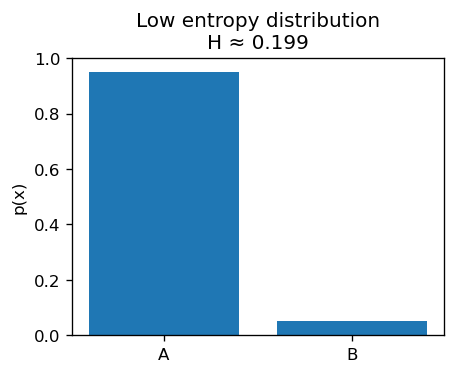

In [66]:
import numpy as np
import matplotlib.pyplot as plt

p_low = np.array([0.95, 0.05])
H_low = -np.sum(p_low * np.log(p_low))

fig, ax = plt.subplots(figsize=(4,3))
ax.bar([0,1], p_low)
ax.set_ylim(0,1)
ax.set_xticks([0,1])
ax.set_xticklabels(["A","B"])
ax.set_title(f"Low entropy distribution\nH ≈ {H_low:.3f}")
ax.set_ylabel("p(x)")
plt.show()

### High entropy (almost certain outcome)

Outcomes are equally likely:
$
P = [0.5,\;0.5]
$

- No outcome is preferred
- Maximum uncertainty
- Entropy is large

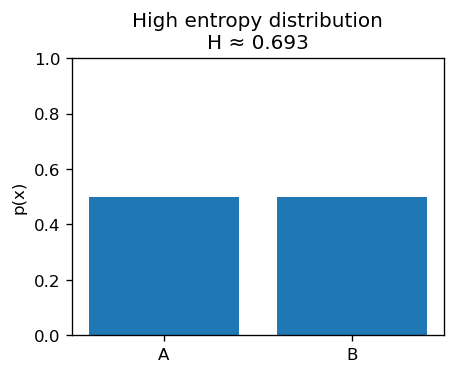

In [67]:
p_high = np.array([0.5, 0.5])
H_high = -np.sum(p_high * np.log(p_high))

fig, ax = plt.subplots(figsize=(4,3))
ax.bar([0,1], p_high)
ax.set_ylim(0,1)
ax.set_xticks([0,1])
ax.set_xticklabels(["A","B"])
ax.set_title(f"High entropy distribution\nH ≈ {H_high:.3f}")
ax.set_ylabel("p(x)")
plt.show()


## 9. Kullback–Leibler (KL) Divergence

$
\mathrm{KL}(P\|Q) = \sum_x p(x)\log\frac{p(x)}{q(x)}
$

**Identity**

$
\mathrm{KL}(P\|Q) = H(P,Q) - H(P)
$



In [68]:
p = np.array([0.4, 0.6])
q = np.array([0.5, 0.5])

kl_pq = np.sum(p*np.log(p/q))
kl_qp = np.sum(q*np.log(q/p))
kl_pq, kl_qp

(0.020135513550688877, 0.020410997260127586)

### Kullback–Leibler (KL) Divergence and Its Relation to Cross-Entropy

KL divergence measures **how different** one probability distribution is from another.

#### Definition

For two discrete distributions $P$ (true) and $Q$ (model):

$$
\mathrm{KL}(P\|Q)
=
\sum_x p(x)\log\frac{p(x)}{q(x)}
$$

Equivalently, as an expectation under $P$:

$$
\mathrm{KL}(P\|Q)
=
\mathbb{E}_{x\sim P}\!\left[\log\frac{p(x)}{q(x)}\right]
$$

#### Interpretation

- $P$ is the distribution that **actually generates the data**
- $Q$ is the distribution we **use to model or encode** that data

KL divergence answers the question:

> *How much extra information (on average) do we need when we use $Q$ instead of the true distribution $P$?*

#### Why KL is always non-negative

KL divergence satisfies:
$
\mathrm{KL}(P\|Q) \ge 0
$
with equality if and only if:
$
P = Q
$

This means:
- Using the true distribution is optimal
- Any mismatch introduces an **information penalty**

### Connection to Cross-Entropy

#### Cross-Entropy Definition

The cross-entropy between $P$ and $Q$ is:
$
H(P,Q) = -\sum_x p(x)\log q(x)
$

This is the **expected code length** when data comes from $P$ but we encode it using $Q$.

### Key Identity (Very Important)

KL divergence decomposes cross-entropy as:
$$
\mathrm{KL}(P\|Q)
=
H(P,Q) - H(P)
$$

where:
- $H(P)$ is the entropy of the data (irreducible uncertainty)
- $H(P,Q)$ is the total uncertainty when using model $Q$

#### Intuitive takeaway

- **Entropy $H(P)$**  
  → uncertainty inherent in the data  
- **Cross-entropy $H(P,Q)$**  
  → uncertainty + model mismatch  
- **KL divergence**  
  → *pure penalty* for using the wrong model

#### Why “pure penalty”?

Notice that:
- $H(P)$ depends **only on the data**
- It does **not depend on the model $Q$**

So when we subtract $H(P)$ from $H(P,Q)$, everything left is due to **model mismatch**.

That is:
$$
\text{penalty from using } Q \text{ instead of } P
=
H(P,Q) - H(P)
$$

This penalty is **pure** because:
- it is zero when $Q = P$,
- it increases as $Q$ diverges from $P$,
- it does not mix in data uncertainty.

So:
> Minimizing cross-entropy is equivalent to minimizing KL divergence from the data distribution to the model.

#### Why this matters in machine learning

In practice:
- $P$ is the empirical data distribution (often one-hot labels)
- $Q$ is the model output (softmax probabilities)

Training with cross-entropy loss is therefore equivalent to:
$
\min_Q \mathrm{KL}(P\|Q)
$

#### Final intuition

> **Entropy is the unavoidable cost.**  
> **KL divergence is the avoidable cost.**

Everything learning can improve lives inside the KL term.

### Visual example: KL divergence for close vs. far distributions

We compare two cases using **three-bin discrete distributions**:

- **Close distributions** → small KL divergence  
- **Far distributions** → large KL divergence  

Recall:
$$
\mathrm{KL}(P\|Q) = \sum_x p(x)\log\frac{p(x)}{q(x)}
$$

KL is an **expectation under $P$**, so bins where $P$ is large matter most.


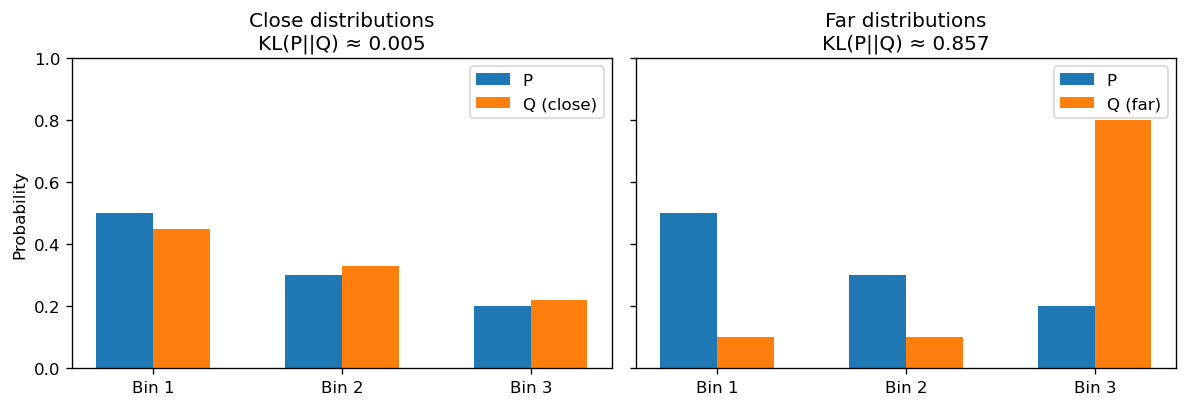

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Three-bin distributions
P = np.array([0.5, 0.3, 0.2])

Q_close = np.array([0.45, 0.33, 0.22])   # close to P
Q_far   = np.array([0.1, 0.1, 0.8])      # very different from P

def kl(P, Q):
    return np.sum(P * np.log(P / Q))

KL_close = kl(P, Q_close)
KL_far   = kl(P, Q_far)

bins = np.arange(3)
labels = ["Bin 1", "Bin 2", "Bin 3"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

# ---- Close distributions ----
ax = axes[0]
ax.bar(bins - 0.15, P, width=0.3, label="P")
ax.bar(bins + 0.15, Q_close, width=0.3, label="Q (close)")
ax.set_xticks(bins)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title(f"Close distributions\nKL(P||Q) ≈ {KL_close:.3f}")
ax.set_ylabel("Probability")
ax.legend()

# ---- Far distributions ----
ax = axes[1]
ax.bar(bins - 0.15, P, width=0.3, label="P")
ax.bar(bins + 0.15, Q_far, width=0.3, label="Q (far)")
ax.set_xticks(bins)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title(f"Far distributions\nKL(P||Q) ≈ {KL_far:.3f}")
ax.legend()

plt.tight_layout()
plt.show()


### Example: KL between 1D Gaussians

For $P=\mathcal{N}(\mu_p,\sigma_p^2)$ and $Q=\mathcal{N}(\mu_q,\sigma_q^2)$:

$$
\mathrm{KL}(P\|Q)
=
\log\frac{\sigma_q}{\sigma_p}
+
\frac{\sigma_p^2 + (\mu_p-\mu_q)^2}{2\sigma_q^2}
-\frac{1}{2}
$$



In [70]:
def kl_gaussian_1d(mu_p, sig_p, mu_q, sig_q):
    return np.log(sig_q/sig_p) + (sig_p**2 + (mu_p-mu_q)**2)/(2*sig_q**2) - 0.5

kl_gaussian_1d(0.0, 1.0, 1.0, 2.0)

0.4431471805599453

### Animation — KL Sensitivity (Discrete)

Fix $P$ and morph $Q_t$. Watch $\mathrm{KL}(P\|Q_t)$ change.

In [71]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

P = np.array([0.6, 0.4])

fig, ax = plt.subplots(figsize=(6,3))
ax.set_ylim(0, 1.0)
ax.set_xticks([0,1])
ax.set_xticklabels(["0","1"])
ax.set_title("KL(P||Q_t) while Q_t changes")
barsP = ax.bar([0,1], P, alpha=0.6, label="P")
barsQ = ax.bar([0,1], [0.5,0.5], alpha=0.6, label="Q_t")
ax.legend(loc="upper right")
txt = ax.text(0.02, 0.92, "", transform=ax.transAxes)

def kl(P,Q):
    return np.sum(P*np.log(P/Q))

def update(t):
    q0 = 0.05 + 0.90*(np.sin(2*np.pi*t/100)*0.5 + 0.5)  # in [0.05,0.95]
    Q = np.array([q0, 1-q0])
    for rect, h in zip(barsQ, Q):
        rect.set_height(h)
    txt.set_text(f"KL(P||Q_t) = {kl(P,Q):.3f}   Q_t = [{Q[0]:.2f},{Q[1]:.2f}]")
    return (*barsQ, txt)

anim = FuncAnimation(fig, update, frames=100, interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

### Why do we use cross-entropy if it includes the data’s natural entropy?

At first glance, cross-entropy seems “wasteful” because it includes the **natural entropy of the data**, which we cannot reduce.

Rewriting KL Divergence Equation:
$
H(P,Q) = H(P) + \mathrm{KL}(P\|Q)
$

So why optimize something that contains an **irreducible term** $H(P)$?

### Key insight

> **Because $H(P)$ is constant with respect to the model.**

When training a model, we can only change $Q$, not the data distribution $P$.

Minimizing cross-entropy:
$
\min_Q H(P,Q)
$
is therefore exactly equivalent to minimizing:
$
\min_Q \mathrm{KL}(P\|Q)
$.
The natural entropy $H(P)$ does not affect optimization because is just a constant offset.

### Why we *cannot* directly minimize KL in practice

Although KL divergence is the “clean” objective conceptually, it requires knowledge of:
$
p(x)
$

But:
- the true data distribution $P$ is unknown,
- we only have **samples** from $P$.

Cross-entropy can be written as an **expectation over data samples**:
$
H(P,Q) = \mathbb{E}_{x\sim P}[-\log q(x)]
$

Start from the **discrete** definition of cross-entropy between a true distribution $P$ and a model distribution $Q$:

$
H(P,Q) = -\sum_x p(x)\log q(x).
$

Now recall the definition of an **expectation** under $P$:

$
\mathbb{E}_{x\sim P}[f(x)] = \sum_x p(x)\,f(x).
$

If we choose the function
$
f(x) = -\log q(x),
$
then plugging into the expectation definition gives:

$
\mathbb{E}_{x\sim P}[-\log q(x)]
= \sum_x p(x)\,(-\log q(x))
= -\sum_x p(x)\log q(x)
= H(P,Q).
$

So we have shown:
$
H(P,Q) = \mathbb{E}_{x\sim P}[-\log q(x)].
$

### Why this is useful for learning

We usually do not know $p(x)$, but we can sample data:
$
x_1, x_2, \dots, x_n \sim P.
$

Then the expectation can be approximated by a sample average (Monte Carlo / empirical risk):

$
H(P,Q)
= \mathbb{E}_{x\sim P}[-\log q(x)]
\approx \frac{1}{n}\sum_{i=1}^n \big(-\log q(x_i)\big).
$

This is exactly the **negative log-likelihood loss** used to train probabilistic models and classifiers. This is directly estimable from data.KL divergence is not.


### Why cross-entropy is the *right* practical objective

Cross-entropy has three crucial properties:

1. **Sample-based**  
   It can be approximated using empirical averages.

2. **Differentiable**  
   It provides clean gradients for learning.

3. **Equivalent to KL minimization**  
   Minimizing cross-entropy automatically minimizes model mismatch.

### Why this is actually desirable

Cross-entropy does **not** “ignore” data entropy but respects it.

It ensures that:
- learning focuses on model quality,
- unavoidable randomness is not confused with model error,
- gradients vanish only when the model truly matches the data.

## 10. Mutual Information

$$
I(X;Y) = \mathrm{KL}\big(p(x,y)\|p(x)p(y)\big)
$$

**Equivalent form**

$$
I(X;Y)
=
\mathbb{E}_{p(x,y)}
\!\left[
\log\frac{p(x,y)}{p(x)p(y)}
\right]
$$



In [73]:
def mutual_information_discrete(pxy):
    pxy = np.array(pxy, dtype=float)
    pxy = pxy / pxy.sum()
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    mi = 0.0
    for i in range(pxy.shape[0]):
        for j in range(pxy.shape[1]):
            if pxy[i,j] > 0:
                mi += pxy[i,j] * np.log(pxy[i,j] / (px[i,0]*py[0,j]))
    return mi

pxy_indep = np.array([[0.25, 0.25],
                      [0.25, 0.25]])

pxy_dep = np.array([[0.40, 0.10],
                    [0.10, 0.40]])

mutual_information_discrete(pxy_indep), mutual_information_discrete(pxy_dep)

(0.0, 0.19274475702175753)

### Mutual Information (MI): A Simple Intuition

Mutual information measures **how much knowing one variable tells us about another**.

If knowing $Y$ reduces our uncertainty about $X$, then $X$ and $Y$ have **positive mutual information**.

#### What MI really measures 

- If $X$ and $Y$ are **independent**, then:
  $
  p(x,y) = p(x)p(y)
  \quad\Rightarrow\quad
  I(X;Y)=0
  $

- If $X$ and $Y$ are **dependent**, then:
  - knowing $Y$ gives information about $X$
  - mutual information is **positive**

### A Simple 2×2 example

Let:
- $X \in \{0,1\}$
- $Y \in \{0,1\}$

Suppose the **joint distribution** is:

| $X \backslash Y$ | 0 | 1 |
|------------------|---|---|
| **0** | 0.40 | 0.10 |
| **1** | 0.10 | 0.40 |

#### Step 1 — Marginal distributions

From the table:
$$
p(X=0)=0.5,\quad p(X=1)=0.5
$$
$$
p(Y=0)=0.5,\quad p(Y=1)=0.5
$$

If $X$ and $Y$ were independent, every entry would be $0.25$, but they are not.

#### Step 2 — Intuition from the table

- When $X=0$, $Y$ is **more likely to be 0**
- When $X=1$, $Y$ is **more likely to be 1**

So:
> Knowing $Y$ gives strong information about $X$, and vice versa.

This implies **high mutual information**.

#### Step 3 — Why MI is positive here

For example, at $(X=0,Y=0)$:
$$
\frac{p(x,y)}{p(x)p(y)} = \frac{0.40}{0.25} > 1
$$

Taking the log and averaging over all cells produces:
$$
I(X;Y) > 0
$$

#### Summary

> **Mutual information measures how far the joint distribution is from independence.**

- $I(X;Y)=0$ → knowing one variable tells you nothing about the other  
- Larger $I(X;Y)$ → stronger statistical dependence  

## 11. Monte Carlo Estimation

Monte Carlo estimation is a general numerical technique for **approximating quantities using random samples**. It is especially useful when exact computation is difficult or impossible.

### Core principle

If a quantity can be written as an **average** or an **integral**, then it can often be approximated by sampling.

Formally, for a function $f(x)$ and a random variable $X$ with distribution $P$:
$$
\mathbb{E}_{x\sim P}[f(x)]
=
\int f(x)\,p(x)\,dx
$$

Monte Carlo estimation replaces this integral with a **sample average**:
$
\mathbb{E}_{x\sim P}[f(x)]
\;\approx\;
\frac{1}{N}\sum_{i=1}^N f(x_i),
\quad x_i \sim P.
$

### Why it works

By the **Law of Large Numbers**, the average of many independent samples converges to the true expected value as the number of samples increases. No assumptions are needed about the shape or dimensionality of $P$.

### What makes Monte Carlo powerful

- Works in **any dimension**
- Requires only the ability to **sample**
- Accuracy improves predictably as more samples are used
- Avoids explicit integration or summation

### Trade-off

- Monte Carlo estimates are **random**
- Error decreases slowly, at rate:
  $
  \mathcal{O}\!\left(\frac{1}{\sqrt{N}}\right)
  $
- High accuracy may require many samples

## . Monte Carlo Estimation of Expectations

$$
\mathbb{E}[f(X)] \approx \frac{1}{N}\sum_{i=1}^N f(x_i),\quad x_i\sim p(x)
$$


[    10     12     16     20     25     32     41     52     66     83
    106    134    170    215    272    345    437    554    701    888
   1125   1425   1804   2285   2894   3665   4641   5878   7443   9426
  11937  15117  19144  24244  30702  38881  49238  62355  78965 100000]


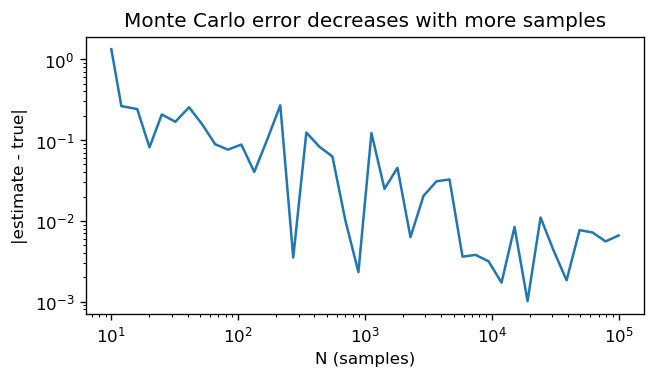

In [75]:
# Monte Carlo convergence: estimate E[X^2] for X~N(0,1) (true value = 1)
true = 1.0
Ns = np.unique(np.logspace(1, 5, 40).astype(int))
print(Ns)

errs = []
for N in Ns:
    X = np.random.normal(size=N)
    est = np.mean(X**2)
    errs.append(abs(est - true))

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(Ns, errs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N (samples)")
ax.set_ylabel("|estimate - true|")
ax.set_title("Monte Carlo error decreases with more samples")
plt.show()


## 12 Maximum Likelihood Estimation (MLE)

**MLE picks the parameter values that make the observed data most likely under the assumed model.**

We observe data points:

$$
x_1, x_2, \dots, x_n
$$

We assume the data were generated i.i.d. from a distribution with parameters $\theta$.

MLE solves:

$$
\hat{\theta} = \arg\max_{\theta} \; \mathcal{L}(\theta)
$$

where the **likelihood** is:

$$
\mathcal{L}(\theta) = p(x_1, x_2, \dots, x_n \mid \theta)
$$

Because observations are i.i.d.:

$$
p(x_1,\dots,x_n\mid\theta) = \prod_{i=1}^n p(x_i\mid\theta)
$$


### Why we use **log-likelihood** instead of likelihood

In probabilistic modeling, we often want to fit a model $q_\theta(x)$ to data
$
x_1, x_2, \dots, x_n \sim P.
$

The most natural objective is the **likelihood**:
$$
\mathcal{L}(\theta)
=
\prod_{i=1}^n q_\theta(x_i),
$$
which measures how probable the observed data is under the model. For simplicity we rewrite $p(x_i\mid\theta)$ as $q_\theta(x_i)$.

So why don’t we optimize this directly?

#### Reason 1 — Products of probabilities are numerically unstable

Probabilities are numbers **less than 1**.

Multiplying many of them quickly produces extremely small values:
$
0.1 \times 0.1 \times \cdots \times 0.1 \;\longrightarrow\; 0
$

This causes:
- numerical underflow,
- loss of precision,
- unstable optimization.

#### Reason 2 — Logs turn products into sums

Taking the logarithm gives the **log-likelihood**:
$$
\log \mathcal{L}(\theta)
=
\sum_{i=1}^n \log q_\theta(x_i).
$$

This has major advantages:
- products → sums
- easier gradients
- numerically stable
- additive contributions per data point

Maximizing likelihood and maximizing log-likelihood are equivalent because $\log$ is monotonic.

#### Reason 3 — Log-likelihood matches expectations and learning theory

The average log-likelihood is:
$
\frac{1}{n}\sum_{i=1}^n \log q_\theta(x_i)
\;\approx\;
\mathbb{E}_{x\sim P}[\log q_\theta(x)].
$

Maximizing log-likelihood is therefore equivalent to **minimizing cross-entropy**:
$
H(P,Q_\theta) = \mathbb{E}_{x\sim P}[-\log q_\theta(x)].
$

This directly connects learning to:
- cross-entropy
- KL divergence
- information theory



### Example 1: Bernoulli / Coin Toss MLE ($\theta$ = probability of Heads)

#### Model
Each toss is modeled as:
$
X \sim \text{Bernoulli}(\theta)
$

- Heads $H$ (or $X=1$) has probability $\theta$  
- Tails $T$ (or $X=0$) has probability $1-\theta$

So for one observation:

- If $x=1$: $p(x\mid\theta)=\theta$
- If $x=0$: $p(x\mid\theta)=1-\theta$

##### Step-by-step likelihood for a specific sequence

Suppose we observe the **exact sequence**:
$
H,\; T,\; H,\; H,\; T
$

Write the probability for each outcome explicitly:

- $P(H)=\theta$
- $P(T)=1-\theta$
- $P(H)=\theta$
- $P(H)=\theta$
- $P(T)=1-\theta$

Because tosses are independent, multiply them:

$
\mathcal{L}(\theta)
= \theta \times (1-\theta) \times \theta \times \theta \times (1-\theta)
$

Group terms:

$
= \underbrace{\theta \times \theta \times \theta}_{3\;\text{heads}}
\times
\underbrace{(1-\theta)\times(1-\theta)}_{2\;\text{tails}}
$

So:

$
\mathcal{L}(\theta)=\theta^3(1-\theta)^2
$

#### General form ($k$ heads out of $n$ tosses)

If we observe $k$ heads and $n-k$ tails, then the likelihood is:

$
\mathcal{L}(\theta)
= \underbrace{\theta \times \cdots \times \theta}_{k\;\text{times}}
\times
\underbrace{(1-\theta)\times\cdots\times(1-\theta)}_{n-k\;\text{times}}
= \theta^k(1-\theta)^{n-k}
$

#### Maximizing the likelihood (using log-likelihood)

Take logs to convert products into sums:

$
\ell(\theta)=\log \mathcal{L}(\theta)
=\log\left(\theta^k(1-\theta)^{n-k}\right)
$

Use log rules (split product into sum):

$
\ell(\theta)
= \log(\theta^k) + \log((1-\theta)^{n-k})
$

Bring down powers:

$
\ell(\theta) = k\log\theta + (n-k)\log(1-\theta)
$

Differentiate and set to zero:

$
\frac{d\ell}{d\theta}
= \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0
$

Solve step by step:

1) Move one term to the other side:

$
\frac{k}{\theta} = \frac{n-k}{1-\theta}
$

2) Cross-multiply:

$
k(1-\theta) = (n-k)\theta
$

3) Expand left side:

$
k - k\theta = (n-k)\theta
$

4) Expand right side:

$
k - k\theta = n\theta - k\theta
$

5) Add $k\theta$ to both sides:

$
k = n\theta
$

6) Divide by $n$:

$
\boxed{\hat{\theta}_{MLE} = \frac{k}{n}}
$

This matches intuition: **MLE equals the empirical frequency of heads**.

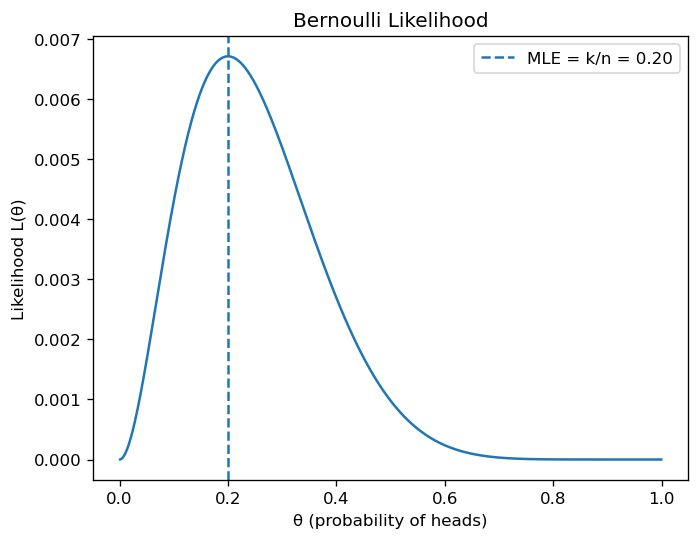

In [76]:

# Visualizing the Bernoulli likelihood for an example:
# Suppose n=10 tosses and k=8 heads
n = 10
k = 2

theta = np.linspace(0.001, 0.999, 1000)
L = theta**k * (1-theta)**(n-k)

plt.figure()
plt.plot(theta, L)
plt.axvline(k/n, linestyle="--", label=f"MLE = k/n = {k/n:.2f}")
plt.xlabel("θ (probability of heads)")
plt.ylabel("Likelihood L(θ)")
plt.title("Bernoulli Likelihood")
plt.legend()
plt.show()



### Example 2: Uniform($a$, $b$) MLE (estimate endpoints)

#### Model
Assume:

$$
X \sim \text{Uniform}(a,b)
$$

The density is:

$$
p(x\mid a,b)=
\begin{cases}
\frac{1}{b-a} & a \le x \le b \\
0 & \text{otherwise}
\end{cases}
$$

#### Likelihood for multiple observations (explicit product)

For i.i.d. samples $x_1,\dots,x_n$, the likelihood is:

$$
\mathcal{L}(a,b)=\prod_{i=1}^n p(x_i\mid a,b)
$$

If **every** $x_i$ lies inside $[a,b]$, then each term equals $\frac{1}{b-a}$:

$$
\mathcal{L}(a,b)=
\underbrace{\frac{1}{b-a}\times \frac{1}{b-a}\times \cdots \times \frac{1}{b-a}}_{n\;\text{times}}
= (b-a)^{-n}
$$

If **any** $x_i$ is outside $[a,b]$, then at least one term is $0$, so:

$$
\mathcal{L}(a,b)=0
$$

So we can write:

$$
\mathcal{L}(a,b)=
\begin{cases}
(b-a)^{-n} & a \le \min(x_i)\ \text{and}\ b \ge \max(x_i) \\
0 & \text{otherwise}
\end{cases}
$$

#### How to maximize it?

When the interval covers the data, likelihood is $(b-a)^{-n}$.

Maximizing $(b-a)^{-n}$ is the same as **minimizing** $(b-a)$ (negative exponent).

So we want the **tightest interval** that still contains all data:

$$
\boxed{\hat{a} = \min(x_i), \quad \hat{b} = \max(x_i)}
$$


In [77]:

np.random.seed(0)
data = np.random.uniform(0, 1, size=20)

a_hat = data.min()
b_hat = data.max()

a_hat, b_hat


(0.02021839744032572, 0.9636627605010293)

In [78]:

# Numerical search for (a,b) without using the analytic formula
def logL_uniform(a, b, x):
    if a <= x.min() and b >= x.max() and b > a:
        return -len(x) * np.log(b - a)
    return -np.inf

a_grid = np.linspace(-0.2, 0.8, 250)
b_grid = np.linspace(0.2, 1.4, 250)

best = (-np.inf, None)
for a in a_grid:
    for b in b_grid:
        ll = logL_uniform(a, b, data)
        if ll > best[0]:
            best = (ll, (a, b))

best_ll, (a_num, b_num) = best
(a_hat, b_hat), (a_num, b_num), best_ll


((0.02021839744032572, 0.9636627605010293),
 (0.016867469879518038, 0.9662650602409637),
 1.0385522186552922)


### Example 3: Gaussian (Normal) MLE for Mean and Variance

#### Model
Assume:

$$
X \sim \mathcal{N}(\mu,\sigma^2)
$$

The density for one observation is:

$$
p(x\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

#### Step 1: Write the likelihood as a product (i.i.d.)

For data $x_1,\dots,x_n$:

$$
\mathcal{L}(\mu,\sigma^2)=\prod_{i=1}^n
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

Write the first few terms explicitly:

$$
\mathcal{L}(\mu,\sigma^2)=
\left(\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right)\right)
\times
\left(\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_2-\mu)^2}{2\sigma^2}\right)\right)
\times \cdots \times
\left(\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_n-\mu)^2}{2\sigma^2}\right)\right)
$$

Now group constants and exponentials.

#### Constants
The constant factor $\frac{1}{\sqrt{2\pi\sigma^2}}$ appears $n$ times, so:

$$
\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n
$$

#### Exponentials
A product of exponentials becomes the exponential of a sum:

$$
\prod_{i=1}^n \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
= \exp\left(-\sum_{i=1}^n \frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

So:

$$
\mathcal{L}(\mu,\sigma^2)
= \left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n
\exp\left(-\sum_{i=1}^n \frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

#### Step 2: Take log-likelihood

Define $\ell(\mu,\sigma^2)=\log\mathcal{L}(\mu,\sigma^2)$.

Apply log rules:

$$
\ell(\mu,\sigma^2)
= \log\left(\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n\right)
+ \log\left(\exp\left(-\sum_{i=1}^n \frac{(x_i-\mu)^2}{2\sigma^2}\right)\right)
$$

Simplify each term:

1) First term (bring down the power):

$$
\log\left(\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n\right)
= n\log\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)
= -\frac{n}{2}\log(2\pi\sigma^2)
$$

2) Second term (log(exp(.)) cancels):

$$
\log\left(\exp(\cdot)\right)=\cdot
\Rightarrow
-\sum_{i=1}^n \frac{(x_i-\mu)^2}{2\sigma^2}
$$

Therefore:

$$
\boxed{
\ell(\mu,\sigma^2)=
-\frac{n}{2}\log(2\pi\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
}
$$

#### Step 3: MLE for $\mu$ 

Only the second term depends on $\mu$. Let:

$$
S(\mu)=\sum_{i=1}^n (x_i-\mu)^2
$$

Then:

$$
\ell(\mu,\sigma^2)=C - \frac{1}{2\sigma^2} S(\mu)
$$

Differentiate w.r.t. $\mu$. For one term:

$$
\frac{d}{d\mu}(x_i-\mu)^2 = 2(x_i-\mu)(-1) = -2(x_i-\mu)
$$

So:

$$
\frac{\partial \ell}{\partial \mu}
= -\frac{1}{2\sigma^2}\sum_{i=1}^n \left(-2(x_i-\mu)\right)
= \frac{1}{\sigma^2}\sum_{i=1}^n (x_i-\mu)
$$

Set equal to zero:

$$
\frac{1}{\sigma^2}\sum_{i=1}^n (x_i-\mu)=0
\Rightarrow
\sum_{i=1}^n (x_i-\mu)=0
$$

Expand:

$$
\sum_{i=1}^n x_i - \sum_{i=1}^n \mu = 0
$$

But $\sum_{i=1}^n \mu = n\mu$, so:

$$
\sum_{i=1}^n x_i - n\mu = 0
\Rightarrow
n\mu = \sum_{i=1}^n x_i
$$

Divide by $n$:

$$
\boxed{\hat{\mu}_{MLE}=\frac{1}{n}\sum_{i=1}^n x_i}
$$

#### Step 4: MLE for $\sigma^2$

Start from:

$$
\ell(\mu,\sigma^2)=
-\frac{n}{2}\log(2\pi\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
$$

Let $S=\sum_{i=1}^n (x_i-\mu)^2$ (treat $\mu$ as fixed when differentiating w.r.t. $\sigma^2$).

Differentiate term by term.

#### Term A
$$
\frac{d}{d\sigma^2}\left(-\frac{n}{2}\log(2\pi\sigma^2)\right)
= -\frac{n}{2}\cdot \frac{1}{\sigma^2}
$$

#### Term B
Rewrite:
$$
-\frac{1}{2\sigma^2}S = -\frac{S}{2}(\sigma^2)^{-1}
$$

Derivative of $(\sigma^2)^{-1}$ is $-(\sigma^2)^{-2}$, so:

$$
\frac{d}{d\sigma^2}\left(-\frac{S}{2}(\sigma^2)^{-1}\right)
= -\frac{S}{2}\cdot\left(-(\sigma^2)^{-2}\right)
= \frac{S}{2(\sigma^2)^2}
$$

#### Combine
$$
\frac{\partial \ell}{\partial \sigma^2}
= -\frac{n}{2}\cdot\frac{1}{\sigma^2}
+ \frac{S}{2(\sigma^2)^2}
$$

Set to zero:

$$
-\frac{n}{2}\cdot\frac{1}{\sigma^2}
+ \frac{S}{2(\sigma^2)^2} = 0
$$

Multiply both sides by $2(\sigma^2)^2$:

$$
-n\sigma^2 + S = 0
\Rightarrow
S = n\sigma^2
$$

So:

$$
\boxed{\hat{\sigma}^2_{MLE}=\frac{1}{n}\sum_{i=1}^n (x_i-\hat{\mu})^2}
$$

**Note:** This uses $1/n$ (MLE). The common $1/(n-1)$ form is the **unbiased** estimator.



## 13 Summary of Terms

This table summarizes the most important quantities and how to interpret them.

| Quantity | Math (discrete) | Intuition |
|---|---|---|
| Probability of one outcome | $p(x)$ | How likely an event is |
| Log-probability | $\log p(x)$ | Additive “score”; relates to information |
| Likelihood | $\mathcal{L}(\theta)=\prod_i p_\theta(x_i)$ | How plausible parameters $\theta$ are given data |
| Log-likelihood | $\ell(\theta)=\sum_i \log p_\theta(x_i)$ | Sum of evidence / negative surprise |
| NLL loss | $\mathrm{NLL}(\theta)=-\ell(\theta)$ | What we minimize in ML training |
| Entropy | $H(p)=-\sum_x p(x)\log p(x)$ | Inherent uncertainty in $p$ |
| Cross-entropy | $H(p,q)=-\sum_x p(x)\log q(x)$ | Surprise when data from $p$ is modeled as $q$ |
| KL-divergence | $\mathrm{KL}(p\|q)=\sum_x p(x)\log\frac{p(x)}{q(x)}$ | Extra surprise / inefficiency from using $q$ instead of $p$ |
| Key identity | $H(p,q)=H(p)+\mathrm{KL}(p\|q)$ | Cross-entropy = uncertainty + mismatch penalty |

---


## 14 Generative models: generation vs. sampling

A **generative model** answers two distinct questions:

1. **Generation (learning)**  
   *What probability distribution should we use to describe the data?*

2. **Sampling (usage)**  
   *Once we have that distribution, how do we generate new data points from it?*

These are conceptually different phases.

#### Starting point: a simple discrete data table

Suppose our observed data consists of pairs $(X,Y)$ with joint distribution:

| $X \backslash Y$ | 0 | 1 |
|------------------|---|---|
| **1** | 0.20 | 0.05 |
| **2** | 0.25 | 0.10 |
| **3** | 0.10 | 0.25 |
| **4** | 0.05 | 0.00 |

This table *is the data distribution* $p_{\text{data}}(x,y)$.

#### Phase 1 — Generation (learning the distribution)

In the **generation phase**, the model’s goal is to **learn or define** a probability distribution that matches the data.

Here, the generative model is simply:
$$
q(x,y) \approx p_{\text{data}}(x,y)
$$

For this toy example, the model could literally **store the table** or estimate it from counts.

This phase answers:
- Which outcomes are likely?
- Which outcomes are rare?
- How are $X$ and $Y$ statistically related?

Nothing is being generated yet, we are only defining a probability law.

#### Phase 2 — Sampling (using the model)

Once the distribution $q(x,y)$ is defined, we can **sample new data** from it.

Sampling means:
1. Randomly draw a pair $(x,y)$ according to the probabilities in the table
2. Treat the sampled pair as a **new synthetic data point**

For example, one possible sample sequence might be:
$$
(2,0),\ (3,1),\ (1,0),\ (3,1),\ \dots
$$

Each draw respects the learned probabilities.

#### Conditional sampling

Because the model defines a **joint distribution**, we can also sample conditionally.

#### Example: sample $X$ given $Y=1$

From the table:
$$
p(x \mid Y=1) = \frac{p(x,1)}{p(Y=1)}
$$

This allows us to:
- fix $Y=1$,
- sample $X$ according to the conditional distribution.

This is the simplest form of **controlled generation**.

#### Why this distinction matters

| Phase | What happens | Typical ML language |
|------|-------------|--------------------|
| Generation | Learn $q(x)$ or $q(x,y)$ | training, fitting, estimating |
| Sampling | Draw new data from $q$ | generation, synthesis |

Many modern models follow this exact split:
- **VAEs**: learn parameters → sample latent variables → decode
- **Diffusion models**: learn denoising distribution → sample by reverse process
- **Autoregressive models**: learn conditional probabilities → sample sequentially

## Summary

> **Generation defines the rules of the random world.  
> Sampling lets you play inside that world.**

This simple table already contains *everything* a generative model needs — modern models just scale this idea to high dimensions.


## 15 Connecting generation & sampling to MLE and cross-entropy training

We now connect the two phases of a generative model to **how models are actually trained** in practice.

#### Phase 1 revisited — Generation = learning a distribution

Recall that in the **generation (learning) phase**, the goal is to learn a model distribution:
$$
q_\theta(x,y)
$$
that matches the true (unknown) data distribution:
$$
p_{\text{data}}(x,y).
$$

We do **not** know $p_{\text{data}}$ explicitly.  
We only observe samples:
$$
(x_1,y_1), (x_2,y_2), \dots, (x_n,y_n).
$$

So the question becomes:

> *How should we choose $\theta$ so that $q_\theta$ explains the observed data well?*

#### Maximum Likelihood Estimation (MLE)

The most natural principle is **maximum likelihood**.

We choose $\theta$ to maximize the probability that the model assigns to the observed data:
$$
\theta^\star
=
\arg\max_\theta
\prod_{i=1}^n q_\theta(x_i,y_i).
$$

This says:
> *A good generative model should assign high probability to the data we actually see.*

#### From likelihood to log-likelihood

Because products of probabilities are numerically unstable, we maximize the **log-likelihood** instead:
$$
\arg\max_\theta
\sum_{i=1}^n \log q_\theta(x_i,y_i).
$$

This does **not change the optimum**, but makes optimization:
- stable,
- additive across samples,
- easy to differentiate.

#### From log-likelihood to cross-entropy

Dividing by $n$, the average log-likelihood becomes:
$$
\frac{1}{n}\sum_{i=1}^n \log q_\theta(x_i,y_i).
$$

As $n$ grows, this empirical average converges to an expectation under the data distribution:
$$
\mathbb{E}_{(x,y)\sim p_{\text{data}}}
\big[\log q_\theta(x,y)\big].
$$

Maximizing log-likelihood is therefore equivalent to minimizing:
$$
\mathbb{E}_{(x,y)\sim p_{\text{data}}}
\big[-\log q_\theta(x,y)\big],
$$
which is exactly the **cross-entropy**:
$$
H\big(p_{\text{data}}, q_\theta\big).
$$

#### Why cross-entropy is the right training objective

Recall the identity:
$$
H(P,Q) = H(P) + \mathrm{KL}(P\|Q).
$$

Here:
- $P = p_{\text{data}}$ (fixed, unknown)
- $Q = q_\theta$ (learnable model)

Since $H(P)$ does **not depend on $\theta$**, minimizing cross-entropy is equivalent to:
$$
\min_\theta \mathrm{KL}\big(p_{\text{data}}\|q_\theta\big).
$$

So training via cross-entropy means:

> **Make the model distribution as close as possible to the data distribution.**

#### Phase 2 revisited — Sampling after training

Once training is complete, we have a learned distribution:
$$
q_{\theta^\star}(x,y).
$$

Now we can **sample from it**:
- generate new $(x,y)$ pairs,
- sample conditionally (e.g., $x \mid y=1$),
- or marginalize as needed.

Most Importantly:
- **MLE / cross-entropy only affects the learning phase**
- **Sampling uses the learned distribution, unchanged**


#### Summary

| Concept | What it does |
|------|-------------|
| MLE | Chooses the best model parameters |
| Log-likelihood | Makes optimization stable |
| Cross-entropy | Turns learning into expectation minimization |
| KL divergence | Measures model–data mismatch |
| Sampling | Uses the learned distribution to generate data |

## A simple 1D generative example

We assume data is generated by a **known function with noise**:

$
y = f(x) + \varepsilon,
\quad \varepsilon \sim \mathcal{N}(0, \sigma^2)
$

Here:
- $x$ is the input (1D)
- $y$ is the output (1D)
- $f(x)$ is the underlying structure
- randomness comes from noise

This already defines a **generative process**.


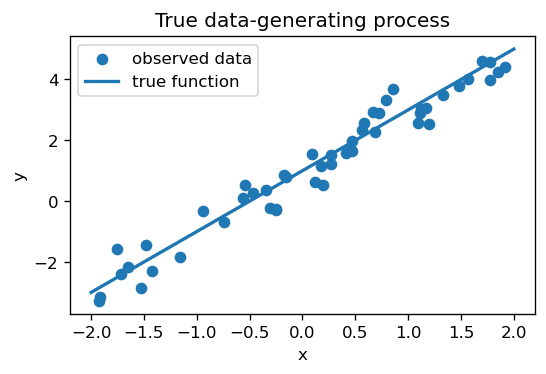

In [79]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# True function
def f_true(x):
    return 2*x + 1

# Generate training data
N = 50
x = np.random.uniform(-2, 2, size=N)
noise = np.random.normal(0, 0.5, size=N)
y = f_true(x) + noise

# Plot data
xs = np.linspace(-2, 2, 200)

plt.figure(figsize=(5,3))
plt.scatter(x, y, label="observed data")
plt.plot(xs, f_true(xs), label="true function", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("True data-generating process")
plt.legend()
plt.show()


### Generation phase: learning a probabilistic model using MLE

In this step, we **learn the parameters of a generative model** from data.

#### What model are we assuming?

We assume that the data is generated by a **linear function with Gaussian noise**:
$$
y = a x + b + \varepsilon,
\quad
\varepsilon \sim \mathcal{N}(0,\sigma^2)
$$

This defines a **conditional probability distribution**:
$$
p(y \mid x; a,b)
=
\mathcal{N}\!\left(y \;\middle|\; a x + b,\; \sigma^2\right)
$$

Our goal in the generation (training) phase is to find the parameters $a$ and $b$ that make the observed data **most likely** under this model.

### Why Maximum Likelihood Estimation (MLE)?

Under the Gaussian noise assumption, the **log-likelihood** of the data is:
$$
\log \mathcal{L}(a,b)
=
-\frac{1}{2\sigma^2}
\sum_{i=1}^n \big(y_i - (a x_i + b)\big)^2
\;+\;\text{constant}
$$

Maximizing this log-likelihood is therefore **equivalent to minimizing the sum of squared errors**.

This is exactly the **least-squares problem**.

So:
> **Least squares = Maximum Likelihood Estimation**  
> *(when noise is Gaussian)*

### What the code does (step by step)

1. Builds a **design matrix** containing the inputs $x$ and a bias term:
   $$
   A =
   \begin{bmatrix}
   x_1 & 1 \\
   x_2 & 1 \\
   \vdots & \vdots \\
   x_n & 1
   \end{bmatrix}
   $$

2. Solves the least-squares problem:
   $$
   \min_{a,b} \sum_{i=1}^n (y_i - (a x_i + b))^2
   $$

3. Obtains the MLE estimates $\hat{a}$ and $\hat{b}$.

4. Defines the learned model:
   $$
   f_{\text{model}}(x) = \hat{a}x + \hat{b}
   $$

5. Plots:
   - the observed data,
   - the true (unknown) generating function,
   - the learned model.

### Why this belongs in a *generative* model discussion

Although this looks like simple regression, it is already a **generative model**:

- We learn a distribution $p(y \mid x)$
- We learn its parameters using MLE
- We can later **sample** new $y$ values given $x$

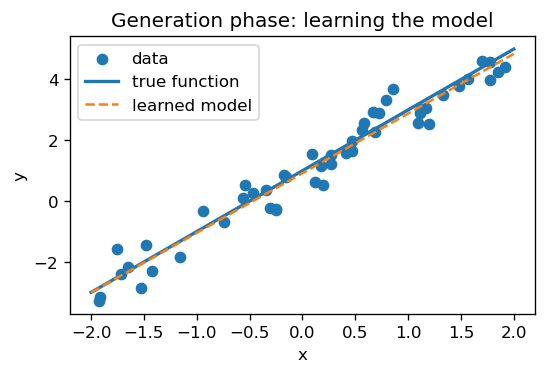

(1.9615916184136912, 0.9195781947622427)

In [80]:
# Fit linear model y = ax + b using least squares (MLE)
A = np.vstack([x, np.ones_like(x)]).T
# do the least squares solution
a_hat, b_hat = np.linalg.lstsq(A, y, rcond=None)[0]

def f_model(x):
    return a_hat*x + b_hat

plt.figure(figsize=(5,3))
plt.scatter(x, y, label="data")
plt.plot(xs, f_true(xs), label="true function", linewidth=2)
plt.plot(xs, f_model(xs), label="learned model", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generation phase: learning the model")
plt.legend()
plt.show()

a_hat, b_hat


## Sampling phase: generating new data from the learned model

After MLE, we have learned a **probabilistic model**, not just a curve.

From the generation (training) phase we obtained:
$
q(y \mid x) = \mathcal{N}\!\left(y \;\middle|\; \hat{a}x + \hat{b},\; \hat{\sigma}^2\right)
$

This means:
- $\hat{a}x + \hat{b}$ is the **mean** of the distribution,
- $\hat{\sigma}^2$ captures the **noise level** in the data.

In the **sampling phase**, we:
1. choose new input values $x$,
2. sample noise $\varepsilon \sim \mathcal{N}(0,\hat{\sigma}^2)$,
3. generate synthetic outputs:
   $$
   y = \hat{a}x + \hat{b} + \varepsilon.
   $$

This produces *new data points* that follow the same statistical rules as the original data

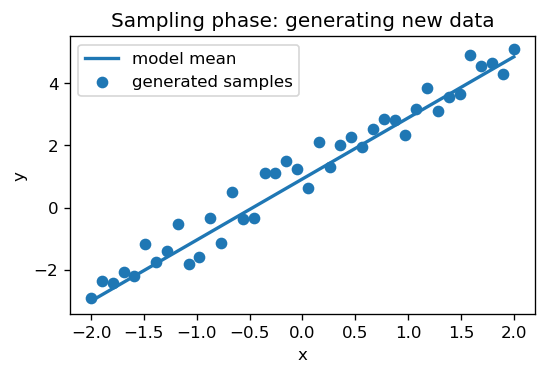

0.46247366646128796

In [81]:
# Estimate noise variance
residuals = y - f_model(x)
sigma_hat = np.std(residuals)

# Sample new data
x_new = np.linspace(-2, 2, 40)
y_sampled = f_model(x_new) + np.random.normal(0, sigma_hat, size=len(x_new))

plt.figure(figsize=(5,3))
plt.plot(xs, f_model(xs), label="model mean", linewidth=2)
plt.scatter(x_new, y_sampled, label="generated samples")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sampling phase: generating new data")
plt.legend()
plt.show()

sigma_hat


## Why Mean Squared Error (MSE) equals Gaussian log-likelihood

This equivalence explains why **MSE is not arbitrary** but it is a probabilistic objective.

#### Step 1 — Assume a probabilistic model

Suppose the data is generated as:
$$
y = f_\theta(x) + \varepsilon,
\quad
\varepsilon \sim \mathcal{N}(0,\sigma^2)
$$

This defines a **conditional distribution**:
$$
p(y \mid x; \theta)
=
\mathcal{N}\!\left(y \;\middle|\; f_\theta(x),\; \sigma^2\right)
$$

#### Step 2 — Write the Gaussian likelihood

For a single data point $(x_i,y_i)$:
$$
p(y_i \mid x_i;\theta)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(y_i - f_\theta(x_i))^2}{2\sigma^2}
\right)
$$

For $n$ independent samples, the likelihood is the product:
$$
\mathcal{L}(\theta)
=
\prod_{i=1}^n p(y_i \mid x_i;\theta)
$$

#### Step 3 — Take the log-likelihood

Taking logs turns the product into a sum:
$$
\log \mathcal{L}(\theta)
=
\sum_{i=1}^n \log p(y_i \mid x_i;\theta)
$$

Substituting the Gaussian form:
$$
\log \mathcal{L}(\theta)
=
-\frac{n}{2}\log(2\pi\sigma^2)
-
\frac{1}{2\sigma^2}
\sum_{i=1}^n (y_i - f_\theta(x_i))^2
$$

#### Step 4 — Identify what depends on the model

The first term:
$$
-\frac{n}{2}\log(2\pi\sigma^2)
$$
does **not** depend on $\theta$.

The only term that depends on the model is:
$$
\sum_{i=1}^n (y_i - f_\theta(x_i))^2
$$

#### Step 5 — Maximizing likelihood = minimizing MSE

Maximizing the log-likelihood is therefore equivalent to minimizing:
$$
\sum_{i=1}^n (y_i - f_\theta(x_i))^2
$$

Dividing by $n$ gives the **Mean Squared Error**:
$$
\mathrm{MSE}
=
\frac{1}{n}
\sum_{i=1}^n (y_i - f_\theta(x_i))^2
$$

#### Final conclusion (important)

> **MSE is the negative log-likelihood of a Gaussian noise model (up to a constant).**

So when you minimize MSE, you are implicitly assuming:
- Gaussian noise
- constant variance
- independent errors

## Summary

| Loss | Implied noise model |
|----|----|
| MSE | Gaussian |
| MAE | Laplace |
| Huber | Gaussian + Laplace |
| Cross-entropy | Categorical / Bernoulli |

Loss functions are **probabilistic assumptions in disguise**.

> **Using MSE means you believe your errors are Gaussian — whether you say so or not.**

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.